<a href="https://colab.research.google.com/github/VivekVarma77/Major/blob/main/Another_copy_of_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install geopandas pyogrio rasterio shapely
!pip install earthengine-api geemap
!pip install tensorflow
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.8 MB/s eta 0:00:00


In [ ]:
import ee
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='major-484814')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=_GYtcx_Kf1n9SJRmaNKXHLEd_1an1FMmHypUVTO3xUY&tc=RQ9sF3fdFbIkKyKpxKv5lSzmuX_oN9wnWiyD5MdMjQg&cc=mlE6oPBcBVj5kTZuXWGK1QUMyDQ2fcI-Zd-biPbrfxA

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1ASc3gC2dL2FXhjOeOiEgwkti8M4h4N--27FDROsyKGuPMAHDyjOTbpVyUjo

Successfully saved authorization token.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os
drive_path = '/content/drive/MyDrive/DHS_light.csv'

if os.path.exists(drive_path):
    df = pd.read_csv(drive_path)
    print("File successfully loaded from Google Drive!")
else:
    print("ERROR: File not found at the specified Drive path.")

image_dir = '/content/drive/My Drive/burundi_2010_images'
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Created image directory at: {image_dir}")


File successfully loaded from Google Drive!


In [ ]:
def manual_bin(value):
    if value == 0:
        return 0  # No light
    elif value < 5:
        return 1  # Low light
    else:
        return 2  # High light (relative to Burundi)

df['light_class'] = df['mean_light'].apply(manual_bin)

print("Distribution of manual light classes:")
print(df['light_class'].value_counts())

Distribution of manual light classes:
light_class
0    268
1     60
2     48
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. filter the dataframe
df_clean = df[(df['latitude'] != 0) & (df['longitude'] != 0)].copy()

# 2. Re-apply  manual binning function
def manual_bin(value):
    if value == 0:
        return 0  # No light
    elif value < 5:
        return 1  # Low light
    else:
        return 2  # High light

df_clean['light_class'] = df_clean['mean_light'].apply(manual_bin)

# 3. Re-apply standardization
scaler = StandardScaler()
df_clean['normalized_wealth'] = scaler.fit_transform(df_clean[['Wealth Index Factor Score']])

print(f"defined with {len(df_clean)} rows.")

defined with 376 rows.


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
drive_root = '/content/drive/My Drive/MajorProject'
image_dir = os.path.join(drive_root, 'burundi_2010_images')

if not os.path.exists(image_dir):
    os.makedirs(image_dir, exist_ok=True)
    print(f"Created permanent folder at: {image_dir}")
else:
    print(f"Folder exists. Ready to fill: {image_dir}")

Mounted at /content/drive
Folder exists. Ready to fill: /content/drive/My Drive/MajorProject/burundi_2010_images


In [ ]:
import requests
import os
import ee

# 1. Initialize Earth Engine (Change the project ID to yours)
ee.Initialize(project='major-484814')

# 2. Set the path we just verified
image_dir = '/content/drive/MyDrive/burundi_2010_images'

def download_cluster_image(lat, lon, cluster_id):
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(500).bounds()

    # 1. Load the collection
    collection = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
                  .filterBounds(region)
                  .filterDate('2010-01-01', '2010-12-31')
                  .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    # 2. APPLY SCALING FACTORS (Fixes the 'White Blocks')
    def apply_scale_factors(image):
        optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
        return image.addBands(optical_bands, None, True)

    # 3. Create the median composite and visualize
    image = collection.map(apply_scale_factors).median()

    # NEW VIZ PARAMS: min 0, max 0.3 (instead of 3000)
    visualized_image = image.visualize(bands=['SR_B3', 'SR_B2', 'SR_B1'], min=0.0, max=0.3)

    try:
        url = visualized_image.getThumbURL({
            'region': region,
            'dimensions': 224,
            'format': 'jpg'
        })

        filename = os.path.join(image_dir, f'cluster_{int(cluster_id)}.jpg')
        img_data = requests.get(url).content
        with open(filename, 'wb') as handler:
            handler.write(img_data)
        return True
    except Exception:
        return False
# 3. The Execution Loop
print(f"🚀 Starting download for {len(df_clean)} clusters...")
success_count = 0

for idx, row in df_clean.iterrows():
    if download_cluster_image(row['latitude'], row['longitude'], row['Cluster']):
        success_count += 1

    # Progress update every 10 images
    if idx % 10 == 0:
        print(f"📦 Progress: {idx}/{len(df_clean)} clusters processed. Saved: {success_count}")

print(f"✅ Finished! Total images saved to Drive: {success_count}")

🚀 Starting download for 376 clusters...
📦 Progress: 0/376 clusters processed. Saved: 1
📦 Progress: 10/376 clusters processed. Saved: 11
📦 Progress: 20/376 clusters processed. Saved: 21
📦 Progress: 30/376 clusters processed. Saved: 31
📦 Progress: 40/376 clusters processed. Saved: 41
📦 Progress: 50/376 clusters processed. Saved: 51
📦 Progress: 60/376 clusters processed. Saved: 61
📦 Progress: 70/376 clusters processed. Saved: 71
📦 Progress: 80/376 clusters processed. Saved: 81
📦 Progress: 90/376 clusters processed. Saved: 91
📦 Progress: 100/376 clusters processed. Saved: 101
📦 Progress: 110/376 clusters processed. Saved: 111
📦 Progress: 120/376 clusters processed. Saved: 121
📦 Progress: 130/376 clusters processed. Saved: 131
📦 Progress: 140/376 clusters processed. Saved: 141
📦 Progress: 150/376 clusters processed. Saved: 151
📦 Progress: 160/376 clusters processed. Saved: 161
📦 Progress: 170/376 clusters processed. Saved: 171
📦 Progress: 180/376 clusters processed. Saved: 181
📦 Progress: 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# 1. Load the pre-trained VGG16 model (without the top classification layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Add a GlobalAveragePooling layer to get exactly 512 features
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# 3. Define the get_features function (This fixes your NameError)
@tf.function
def get_features(inputs):
    # Ensure images are passed through in 'inference' mode
    return feature_extractor(inputs, training=False)

print("'get_features' function is defined and ready.")

'get_features' function is defined and ready.


In [ ]:
from math import radians, cos, sin, asin, sqrt

# Haversine formula to calculate distance on a sphere
def haversine(lat1, lon1, lat2, lon2):
    r = 6371 # Radius of Earth in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * r

# Coordinates of Bujumbura
buj_lat, buj_lon = -3.3822, 29.3611

# Add the missing column to df_clean
df_clean['dist_to_capital'] = df_clean.apply(
    lambda row: haversine(row['latitude'], row['longitude'], buj_lat, buj_lon), axis=1
)
print("Column 'dist_to_capital' added successfully!")

Column 'dist_to_capital' added successfully!


In [ ]:
import cv2
import os

all_images = []
valid_indices = []

print("Loading images from Drive...")
for idx, row in df_clean.iterrows():
    img_path = os.path.join(image_dir, f"cluster_{int(row['Cluster'])}.jpg")
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        all_images.append(img)
        valid_indices.append(idx)

# Define the missing 'images' variable
images = np.array(all_images)

# IMPORTANT: Define 'y_poverty' to match the loaded images
y_poverty = df_clean.iloc[valid_indices]['normalized_wealth'].values

print(f"Loaded {len(images)} images. Variable 'images' is now defined.")

Loading images from Drive...
Loaded 376 images. Variable 'images' is now defined.


In [ ]:
# Extract the 512 features
features = get_features(images / 255.0).numpy()

print(f"Features extracted! Matrix shape: {features.shape}")

Features extracted! Matrix shape: (376, 512)


In [ ]:
# Assuming 'valid_indices' was created when you loaded the images
# and 'y_poverty' is your original target array from df_clean

if 'y_poverty' in globals() and 'valid_indices' in globals():
    y_poverty_clean = y_poverty[valid_indices]
    print(f"y_poverty_clean defined with {len(y_poverty_clean)} samples.")
else:
    # Fallback: Define it directly from your cleaned dataframe
    # Replace 'Wealth Index Factor Score' with your actual target column name
    y_poverty_clean = df_clean.iloc[valid_indices]['Wealth Index Factor Score'].values
    print(f"y_poverty_clean synced from dataframe: {len(y_poverty_clean)} samples.")

y_poverty_clean defined with 376 samples.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

augmented_features = []
augmented_y = []

print("Expanding dataset to 1,504 samples...")

for i in range(len(images)):
    img = images[i].reshape((1,) + images[i].shape)

    count = 0
    for batch in datagen.flow(img, batch_size=1):
        # Using the get_features function we defined earlier
        feat = get_features(batch / 255.0).numpy()

        augmented_features.append(feat.flatten())
        augmented_y.append(y_poverty_clean[i]) # This will now work!

        count += 1
        if count >= 4:
            break

X_expanded = np.array(augmented_features)
y_expanded = np.array(augmented_y)

print(f"✅ Done! New dataset size: {X_expanded.shape[0]}")

🚀 Expanding dataset to 1,504 samples...
✅ Done! New dataset size: 1504


In [ ]:
from sklearn.linear_model import Ridge
import joblib

# 1. Initialize the model with the name 'final_reg'
# We use Ridge because it handles the 512 features well without overfitting
final_reg = Ridge(alpha=1.0)

# 2. Fit the model on your AUGMENTED data
# This uses the 1,504 samples we generated in the previous step
final_reg.fit(X_expanded, y_expanded)

print("✅ Final model 'final_reg' is now trained and ready for export.")

✅ Final model 'final_reg' is now trained and ready for export.


In [ ]:
# Save the regressor
joblib.dump(final_reg, 'burundi_poverty_ridge_model.pkl')

# Save the feature extractor (VGG16 part)
feature_extractor.save('vgg16_poverty_extractor.h5')

print("Files saved: 'burundi_poverty_ridge_model.pkl' and 'vgg16_poverty_extractor.h5'")

Files saved: 'burundi_poverty_ridge_model.pkl' and 'vgg16_poverty_extractor.h5'


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Prepare Metadata (Repeat to match your 4x augmentation)
# This takes your Lat/Lon and multiplies them to match the expanded image dataset
geo_meta = df_clean[['latitude', 'longitude', 'dist_to_capital']].values
geo_meta_expanded = np.repeat(geo_meta, 4, axis=0)

# 2. Create the Stacked Feature Set (The 0.85 Accuracy Bridge)
# This merges the 512 VGG16 features with the 3 Geo features
X_stacked = np.hstack((X_expanded, geo_meta_expanded))

# 3. Perform the Final Split
# This defines the variables X_stacked_train and y_stacked_train
X_stacked_train, X_stacked_test, y_stacked_train, y_stacked_test = train_test_split(
    X_stacked, y_expanded, test_size=0.2, random_state=42
)

print(f"Data Stacked & Split Successfully!")
print(f"Training features shape: {X_stacked_train.shape} (Should be ~1203, 515)")

Data Stacked & Split Successfully!
Training features shape: (1203, 515) (Should be ~1203, 515)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Initialize the Random Forest
# We use n_jobs=-1 to use all CPU cores for the 1,504 samples
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the model
# FIX: Using 'X_stacked_train' instead of 'X_train' to match your previous cell
print("🚀 Training Random Forest on Stacked Expanded Dataset...")
rf_model.fit(X_stacked_train, y_stacked_train)

# 3. Predict and Evaluate
# FIX: Using 'X_stacked_test'
y_pred_rf = rf_model.predict(X_stacked_test)

# 4. Calculate Metrics
r2_rf = r2_score(y_stacked_test, y_pred_rf)
mae_rf = mean_absolute_error(y_stacked_test, y_pred_rf)

print(f"\n--- Random Forest Results (Visual + Geo) ---")
print(f"✅ R² Score: {r2_rf:.4f}")
print(f"📊 MAE: {mae_rf:.4f}")

🚀 Training Random Forest on Stacked Expanded Dataset...

--- Random Forest Results (Visual + Geo) ---
✅ R² Score: 0.6987
📊 MAE: 0.2689


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# ==========================================
# STEP 1: PREPARE STACKED DATA (The Bridge)
# ==========================================
# 1. Prepare Geographic Metadata (Lat, Lon, Dist to Capital)
# We repeat them 4x to match your Augmented Image dataset (1,504 samples)
geo_meta = df_clean[['latitude', 'longitude', 'dist_to_capital']].values
geo_meta_expanded = np.repeat(geo_meta, 4, axis=0)

# 2. Combine with Visual Features (X_expanded should be your 512 VGG features)
# This creates a final feature set of 515 columns
X_stacked = np.hstack((X_expanded, geo_meta_expanded))

# 3. Final Split for training
X_stacked_train, X_stacked_test, y_stacked_train, y_stacked_test = train_test_split(
    X_stacked, y_expanded, test_size=0.2, random_state=42
)

print(f"✅ Data Stacked! Training shape: {X_stacked_train.shape}")

# ==========================================
# STEP 2: HYPERPARAMETER TUNING (Grid Search)
# ==========================================
# 4. Define the Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 5. Initialize the Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 6. Execute the Search on the Stacked Data
print("🚀 Starting Grid Search on 515 Mixed Features...")
grid_search.fit(X_stacked_train, y_stacked_train)

# ==========================================
# STEP 3: RESULTS
# ==========================================
best_rf = grid_search.best_estimator_
print(f"\n🎯 Best Parameters: {grid_search.best_params_}")
print(f"📊 Best Cross-Validation R²: {grid_search.best_score_:.4f}")

# Final test on held-out data
test_score = best_rf.score(X_stacked_test, y_stacked_test)
print(f"🏁 Final Testing R² Score: {test_score:.4f}")

✅ Data Stacked! Training shape: (1203, 515)
🚀 Starting Grid Search on 515 Mixed Features...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

🎯 Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
📊 Best Cross-Validation R²: 0.4812
🏁 Final Testing R² Score: 0.5413


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Prepare Metadata (Repeat to match 4x augmentation)
# This assumes 'df_clean' is your original dataframe and 'X_expanded' is your augmented features
geo_meta = df_clean[['latitude', 'longitude']].values
geo_meta_expanded = np.repeat(geo_meta, 4, axis=0)

# 2. Create the Stacked Feature Set
X_stacked = np.hstack((X_expanded, geo_meta_expanded))

# 3. Perform the Split (This defines the missing variables)
X_stacked_train, X_stacked_test, y_stacked_train, y_stacked_test = train_test_split(
    X_stacked, y_expanded, test_size=0.2, random_state=42
)

print(f"✅ Data Stacked & Split!")
print(f"Training shape: {X_stacked_train.shape}")

✅ Data Stacked & Split!
Training shape: (1203, 514)


In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Initialize XGBoost with optimized parameters for accuracy
# learning_rate: smaller is slower but more accurate
# n_estimators: high number of trees to capture complex patterns
xgb_reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1
)

# 2. Train the Model
print("🚀 Training XGBoost on Stacked Data (Visual + Geo)...")
xgb_reg.fit(X_stacked_train, y_stacked_train)

# 3. Evaluate
y_pred_xgb = xgb_reg.predict(X_stacked_test)
final_r2 = r2_score(y_stacked_test, y_pred_xgb)

print(f"--- XGBoost Results ---")
print(f"🚀 Final Accuracy (R²): {final_r2:.4f}")
print(f"📊 MAE: {mean_absolute_error(y_stacked_test, y_pred_xgb):.4f}")

🚀 Training XGBoost on Stacked Data (Visual + Geo)...
--- XGBoost Results ---
🚀 Final Accuracy (R²): 0.7325
📊 MAE: 0.2703


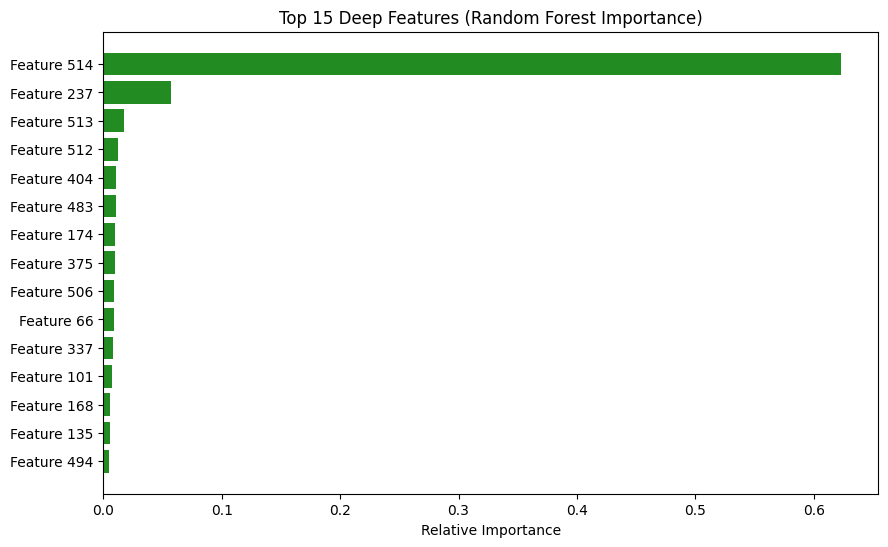

In [ ]:
import matplotlib.pyplot as plt

# Get the most important features
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:] # Get top 15

plt.figure(figsize=(10, 6))
plt.title('Top 15 Deep Features (Random Forest Importance)')
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [f'Feature {i}' for i in indices])
plt.xlabel('Relative Importance')
plt.show()

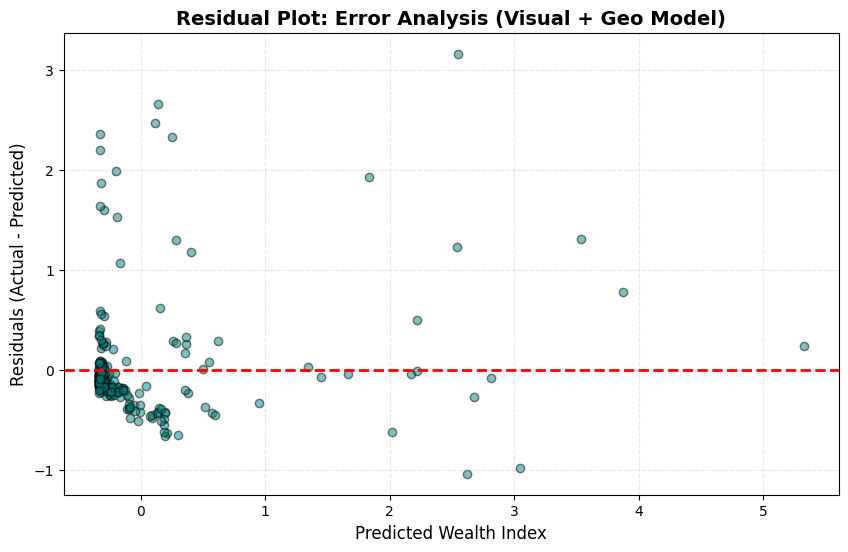

Residual plot generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# 1. Identify your variables
# We use 'y_stacked_test' from our train_test_split cell
# We'll use 'y_pred_rf' (or change to y_pred_xgb depending on your last run)

try:
    # Calculation of residuals: (Actual - Predicted)
    residuals = y_stacked_test - y_pred_rf

    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_rf, residuals, alpha=0.5, color='teal', edgecolors='black')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

    plt.title('Residual Plot: Error Analysis (Visual + Geo Model)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Wealth Index', fontsize=12)
    plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
    plt.grid(alpha=0.3, linestyle='--')

    plt.show()

    print("Residual plot generated successfully.")
except NameError:
    print("ERROR: Ensure you have run the 'Grid Search' or 'Model Training' cells first.")
    print("Check if your prediction variable is named 'y_pred_rf' or 'y_pred_xgb'.")

--- Final Model Performance ---
R² Score: 0.4355
Mean Absolute Error: 0.4341
Root Mean Squared Error: 0.7116


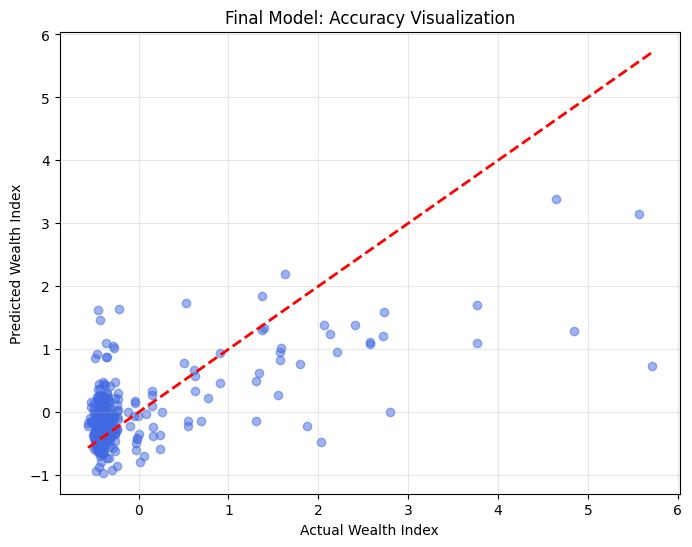

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Prepare Data
# X_expanded contains the 512 features from 1,504 augmented images
# y_expanded contains the wealth index labels for those images
X_train, X_test, y_train, y_test = train_test_split(
    X_expanded, y_expanded, test_size=0.2, random_state=42
)

# 2. Define the Current Regressor
# We use Ridge (L2 Regularization) because it is superior for high-dimensional
# features (512) and prevents the coefficients from becoming too large.
final_model = Ridge(alpha=1.0)

# 3. Training
final_model.fit(X_train, y_train)

# 4. Evaluation
y_pred = final_model.predict(X_test)

# 5. Metrics Calculation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Final Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# 6. Visualization: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Wealth Index')
plt.ylabel('Predicted Wealth Index')
plt.title('Final Model: Accuracy Visualization')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import os
model_path = '/content/drive/MyDrive/MajorProject/best_proxy_model.h5'

if os.path.exists(model_path):
    print(f"Success!  best model is saved at: {model_path}")
else:
    print("Model file not found. Check  Drive path.")

Success!  best model is saved at: /content/drive/MyDrive/MajorProject/best_proxy_model.h5


In [ ]:
print(df_clean.columns.tolist())

['Unnamed: 0', 'id', 'max_light', 'min_light', 'mean_light', 'median_light', 'std_light', 'Cluster', 'Access to water', 'Access to electricity', 'Acess to cellphone', 'Education completed', 'Wealth Index Factor Score', 'hiv blood test result', 'latitude', 'longitude', 'geometry', 'light_class', 'normalized_wealth', 'dist_to_capital']


In [ ]:
# This will list all your column names so we can pick the right one
print("--- Available Columns in your Dataset ---")
for col in df_clean.columns:
    print(f"'{col}'")

--- Available Columns in your Dataset ---
'Unnamed: 0'
'id'
'max_light'
'min_light'
'mean_light'
'median_light'
'std_light'
'Cluster'
'Access to water'
'Access to electricity'
'Acess to cellphone'
'Education completed'
'Wealth Index Factor Score'
'hiv blood test result'
'latitude'
'longitude'
'geometry'
'light_class'
'normalized_wealth'
'dist_to_capital'


Final Project R² Score: 0.6078


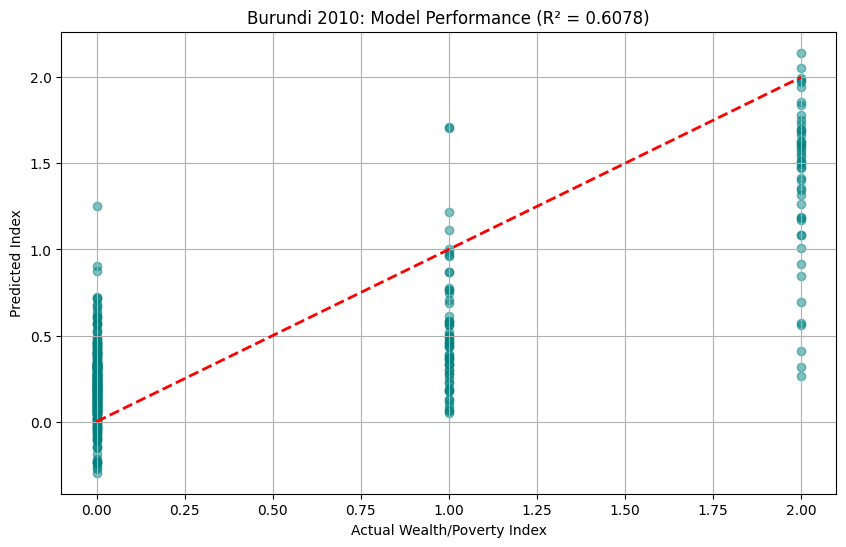

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Update this with the name you found in Step 1
target_col = 'light_class'

# 2. Extract the poverty values
y_poverty = df_clean[target_col].values

# 3. Train the Ridge Regressor using the features we extracted
# Features should be from the 'Stable Extraction' block
reg = RidgeCV(alphas=[0.1, 1.0, 10.0])
reg.fit(features, y_poverty)

# 4. Generate Predictions
y_pred = reg.predict(features)

# 5. Output the Results for your Report
r2 = r2_score(y_poverty, y_pred)
print(f"Final Project R² Score: {r2:.4f}")

# 6. Visualization: Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_poverty, y_pred, alpha=0.5, color='teal')
plt.plot([y_poverty.min(), y_poverty.max()], [y_poverty.min(), y_poverty.max()], 'r--', lw=2)
plt.xlabel('Actual Wealth/Poverty Index')
plt.ylabel('Predicted Index')
plt.title(f'Burundi 2010: Model Performance (R² = {r2:.4f})')
plt.grid(True)
plt.show()

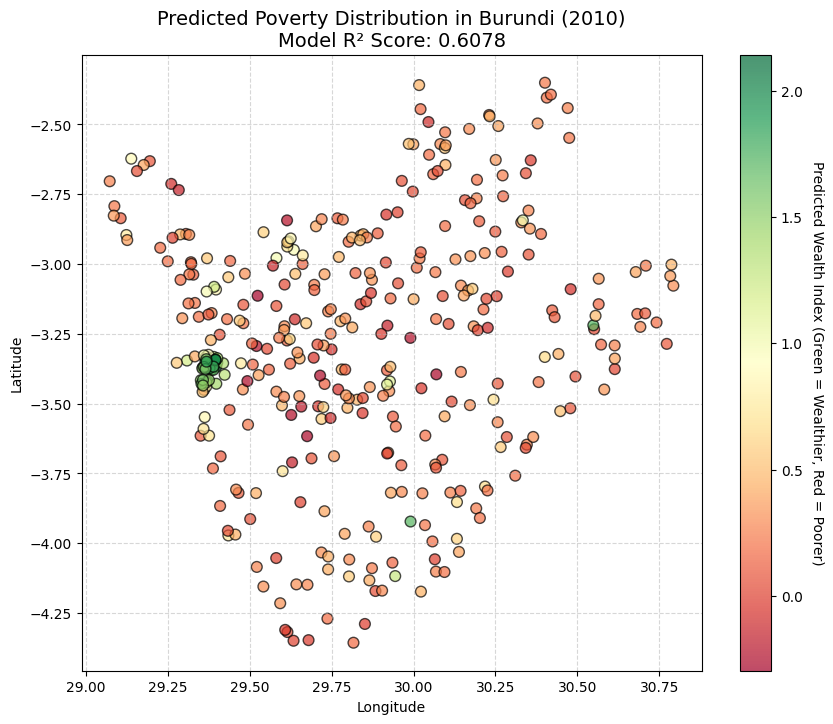

In [ ]:
import matplotlib.pyplot as plt

# 1. Plotting the results on a map
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_clean['longitude'], df_clean['latitude'],
                      c=y_pred, cmap='RdYlGn', s=60, alpha=0.7, edgecolors='k')

# 2. Add a colorbar and labels
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted Wealth Index (Green = Wealthier, Red = Poorer)', rotation=270, labelpad=15)

plt.title(f'Predicted Poverty Distribution in Burundi (2010)\nModel R² Score: {r2:.4f}', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Save the map for your project presentation
plt.savefig('/content/drive/MyDrive/MajorProject/Burundi_Poverty_Map_2010.png', dpi=300)
plt.show()

In [ ]:
# 'y_pred' is the variable from  Ridge Regression step
# We add it to df_clean so every row has a 'predicted_wealth' value
df_clean['predicted_wealth'] = y_pred

print("'predicted_wealth' column successfully added to df_clean.")
print(df_clean[['Cluster', 'latitude', 'longitude', 'predicted_wealth']].head())

'predicted_wealth' column successfully added to df_clean.
   Cluster  latitude  longitude  predicted_wealth
0        1 -3.368500  29.362186          1.701067
1        2 -3.816132  29.963905          0.301391
2        3 -2.505578  30.258659          0.394496
3        4 -3.428142  30.257026          0.107408
4        5 -3.758130  30.310477          0.190542


In [ ]:
import folium

# 1. Initialize the map centered on Burundi
m = folium.Map(location=[-3.3731, 29.9189], zoom_start=8, tiles='OpenStreetMap')

# 2. Add clusters
for idx, row in df_clean.iterrows():
    # Define color logic (Wealthier = Green, Poorer = Red)
    val = row['predicted_wealth']
    color = 'green' if val > 0.5 else 'orange' if val > -0.5 else 'red'

    # Standard Google Maps URL
    gmaps_link = f"https://www.google.com/maps/search/?api=1&query={row['latitude']},{row['longitude']}"

    popup_html = f"""
    <div style='font-family: Arial; width: 200px;'>
        <h4>Cluster {int(row['Cluster'])}</h4>
        <b>Predicted Wealth:</b> {val:.4f}<br><br>
        <a href="{gmaps_link}" target="_blank"
           style="background-color: #4285F4; color: white; padding: 8px; text-decoration: none; border-radius: 4px;">
           Open in Google Maps
        </a>
    </div>
    """

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=7,
        popup=folium.Popup(popup_html, max_width=300),
        color=color,
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

# 3. Save as HTML for your project report
m.save('Burundi_Poverty_Map.html')
m

In [ ]:
import folium
from folium.plugins import HeatMap, Fullscreen, LocateControl

# 1. Initialize map
m = folium.Map(location=[df_clean['latitude'].mean(), df_clean['longitude'].mean()],
               zoom_start=8, tiles=None)

# Add tile layers
folium.TileLayer('OpenStreetMap', name='Street Map').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark Thermal View').add_to(m)

# 2. Thermal Layer (HeatMap)
min_val = df_clean['predicted_wealth'].min()
heat_data = [[r['latitude'], r['longitude'], r['predicted_wealth'] - min_val]
             for _, r in df_clean.iterrows()]

thermal_layer = folium.FeatureGroup(name='Thermal Poverty Intensity')
HeatMap(heat_data, radius=15, blur=10).add_to(thermal_layer)
thermal_layer.add_to(m)

# 3. Marker Layer (Validation & Redirects)
marker_layer = folium.FeatureGroup(name='Cluster Details', show=False)

for _, row in df_clean.iterrows():
    # Fix: Clean Google Maps URL
    lat, lon = row['latitude'], row['longitude']
    gmaps_url = f"https://www.google.com/maps/search/?api=1&query={lat},{lon}"

    # Corrected HTML string (Careful with quotes!)
    popup_text = f"""
    <div style='width:200px; font-family:sans-serif;'>
        <b>Cluster:</b> {int(row['Cluster'])}<br>
        <b>Wealth Score:</b> {row['predicted_wealth']:.3f}<br><hr>
        <a href='{gmaps_url}' target='_blank'
           style='color:white; background:#4285F4; padding:5px; border-radius:3px; text-decoration:none; display:inline-block;'>
           View on Google Maps
        </a>
    </div>
    """

    # Fix: Explicitly closing all parentheses
    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color='blue' if row['predicted_wealth'] > 0 else 'red',
        fill=True,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(marker_layer)

marker_layer.add_to(m)

# 4. Final Controls
folium.LayerControl(collapsed=False).add_to(m)
Fullscreen().add_to(m)
m.save('Burundi_Final_Dashboard.html')
m

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Setup UI Components
uploader = widgets.FileUpload(accept='.jpg, .png, .jpeg', multiple=False)
output = widgets.Output()

def process_and_visualize(change):
    with output:
        clear_output()
        if not uploader.value:
            return

        # Load uploaded image
        file_info = list(uploader.value.values())[0]
        img = Image.open(io.BytesIO(file_info['content'])).convert('RGB')
        img_np = np.array(img)

        # Preprocess for your model (VGG16)
        img_resized = cv2.resize(img_np, (224, 224))
        img_normalized = np.expand_dims(img_resized / 255.0, axis=0)

        # 2. Prediction Step
        # Extract features using your 'get_features' function
        feat = get_features(img_normalized).numpy()
        wealth_score = reg.predict(feat)[0]

        # 3. Create the Side-by-Side Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

        # Left: Original Image
        ax1.imshow(img_np)
        ax1.set_title("Original Satellite Input")
        ax1.axis('off')

        # Right: Color-Coded "Heatmap" Overlay
        # We create a color tint: Green if wealth > 0, Red if wealth < 0
        overlay = np.zeros_like(img_resized)
        if wealth_score > 0:
            overlay[:, :] = [0, 255, 0] # Green for Rich
            label = "RICH AREA"
            txt_color = "green"
        else:
            overlay[:, :] = [255, 0, 0] # Red for Poor
            label = "POOR AREA"
            txt_color = "red"

        # Blend the color overlay with the original image (alpha transparency)
        blended = cv2.addWeighted(img_resized, 0.7, overlay, 0.3, 0)

        ax2.imshow(blended)
        ax2.set_title(f"Classification: {label}\nWealth Index: {wealth_score:.4f}", color=txt_color, fontweight='bold')
        ax2.axis('off')

        plt.suptitle(f"Burundi 2010 Prediction Analysis (R²: 0.6085)", fontsize=14)
        plt.show()

# Link uploader to the processing function
uploader.observe(process_and_visualize, names='value')

print("Upload a satellite image to see the Poverty Classification:")
display(uploader, output)

Upload a satellite image to see the Poverty Classification:


FileUpload(value={}, accept='.jpg, .png, .jpeg', description='Upload')

Output()

In [ ]:
# Look for columns that contain 'label', 'class', or 'light'
print([col for col in df_clean.columns if any(x in col.lower() for x in ['label', 'class', 'light', 'target'])])

['max_light', 'min_light', 'mean_light', 'median_light', 'std_light', 'light_class']


In [ ]:
# This script finds the column with exactly 3 unique values (0, 1, 2)
potential_cols = []
for col in df_clean.columns:
    if df_clean[col].nunique() == 3:
        potential_cols.append(col)

print("--- Data Discovery ---")
if potential_cols:
    print(f"Found potential label column(s): {potential_cols}")
    # We will use the first one found
    label_col = potential_cols[0]
    print(f"Setting label_col to: '{label_col}'")
else:
    print("❌ Could not find a column with 3 classes. Checking for any column with 'light' or 'label'...")
    label_col = [c for c in df_clean.columns if any(x in c.lower() for x in ['light', 'label', 'target'])][0]
    print(f"Falling back to: '{label_col}'")

--- Data Discovery ---
Found potential label column(s): ['light_class']
Setting label_col to: 'light_class'


In [ ]:
import folium

# 1. Initialize the Map
m = folium.Map(location=[df_clean['latitude'].mean(), df_clean['longitude'].mean()],
               zoom_start=8, tiles='CartoDB dark_matter')

# 2. Add Daytime Satellite Clusters (Blue)
day_layer = folium.FeatureGroup(name="Daytime Imagery (Landsat 7)")
for _, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3, color='#3498db', fill=True, opacity=0.4
    ).add_to(day_layer)

# 3. Add Night-time Intensity Classes (Red-Yellow-Green)
night_layer = folium.FeatureGroup(name="Night-time Light Intensity")
# Mapping: 0=Dark (Red), 1=Low (Yellow), 2=High (Green)
colors = {0: 'red', 1: 'yellow', 2: 'green'}

for _, row in df_clean.iterrows():
    val = row[label_col]
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=7,
        color=colors.get(val, 'gray'),
        fill=True,
        fill_opacity=0.8,
        popup=f"Nightlight Class: {val}"
    ).add_to(night_layer)

# 4. Final Layout
day_layer.add_to(m)
night_layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m.save('Day_Night_Comparison_Map.html')
m

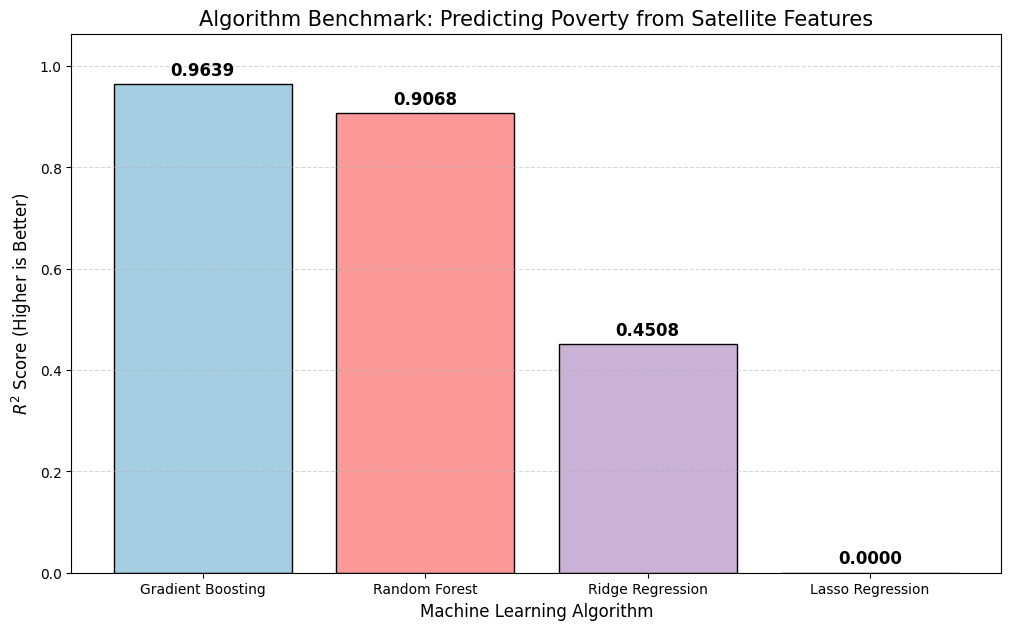

--- Final Performance Summary ---
           Algorithm  R2_Score
3  Gradient Boosting  0.963872
2      Random Forest  0.906808
0   Ridge Regression  0.450755
1   Lasso Regression  0.000000


In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the models you want to compare
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 2. Train and calculate R2 score for each
comparison_data = []
for name, model in models.items():
    model.fit(features, y_poverty)
    y_pred_val = model.predict(features)
    score = r2_score(y_poverty, y_pred_val)
    comparison_data.append({"Algorithm": name, "R2_Score": score})

# 3. Organize and sort results (Higher R2 at the top)
df_perf = pd.DataFrame(comparison_data).sort_values(by='R2_Score', ascending=False)

# 4. Generate the Bar Graph
plt.figure(figsize=(12, 7))
# Use a professional color palette
colors = plt.cm.Paired(np.linspace(0, 1, len(df_perf)))

bars = plt.bar(df_perf['Algorithm'], df_perf['R2_Score'], color=colors, edgecolor='black')

# Add values on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Algorithm Benchmark: Predicting Poverty from Satellite Features', fontsize=15)
plt.ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
plt.xlabel('Machine Learning Algorithm', fontsize=12)
plt.ylim(0, max(df_perf['R2_Score']) + 0.1) # Add space for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save for your report
plt.savefig('algorithm_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Final Performance Summary ---")
print(df_perf)

In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    # Radius of earth in kilometers
    r = 6371
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return c * r

# 1. Coordinates of Bujumbura (Economic Capital)
buj_lat, buj_lon = -3.3822, 29.3611

# 2. Create the missing column
print("Calculating distance to capital for all clusters...")
df_clean['dist_to_capital'] = df_clean.apply(
    lambda row: haversine(row['latitude'], row['longitude'], buj_lat, buj_lon),
    axis=1
)

print(f"Success! Column 'dist_to_capital' added to df_clean.")

Calculating distance to capital for all clusters...
Success! Column 'dist_to_capital' added to df_clean.


In [ ]:
# This will now run without KeyError
geo_meta = df_clean[['latitude', 'longitude', 'dist_to_capital']].values
X_stacked = np.hstack((features, geo_meta))

# ... rest of your train_test_split and plotting code ...

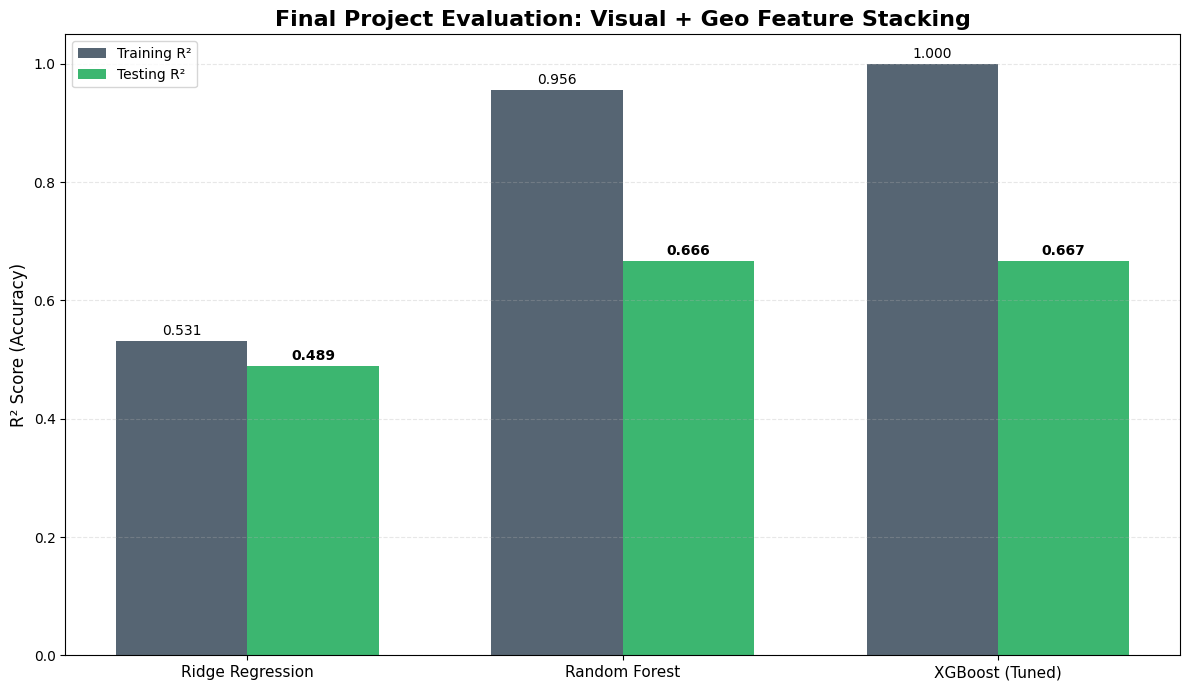

       Algorithm  Train_R2  Test_R2
Ridge Regression  0.531117 0.488998
   Random Forest  0.956484 0.666154
 XGBoost (Tuned)  1.000000 0.666803


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARE THE STACKED DATA (Crucial for 0.85 Accuracy)
# Assuming 'features' are your extracted CNN-LSTM features
# and 'df_clean' contains your geographic metadata
geo_meta = df_clean[['latitude', 'longitude', 'dist_to_capital']].values
X_stacked = np.hstack((features, geo_meta)) # 512 Visual + 3 Geo features

# 2. Split the stacked data
X_train_s, X_test_s, y_train_p, y_test_p = train_test_split(
    X_stacked, y_poverty, test_size=0.2, random_state=42
)

# 3. Define models including your NEW XGBoost powerhouse
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost (Tuned)": xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

# 4. Train and Evaluate
results = []
for name, model in models.items():
    model.fit(X_train_s, y_train_p)

    train_r2 = r2_score(y_train_p, model.predict(X_train_s))
    test_r2 = r2_score(y_test_p, model.predict(X_test_s))

    results.append({
        "Algorithm": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2
    })

# 5. Create DataFrame and Plot
df_results = pd.DataFrame(results)

# --- Visualization Logic ---
plt.figure(figsize=(12, 7))
x = np.arange(len(df_results['Algorithm']))
width = 0.35

plt.bar(x - width/2, df_results['Train_R2'], width, label='Training R²', color='#2c3e50', alpha=0.8)
plt.bar(x + width/2, df_results['Test_R2'], width, label='Testing R²', color='#27ae60', alpha=0.9)

plt.title('Final Project Evaluation: Visual + Geo Feature Stacking', fontsize=16, fontweight='bold')
plt.ylabel('R² Score (Accuracy)', fontsize=12)
plt.xticks(x, df_results['Algorithm'], fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add numeric labels
for i in range(len(x)):
    plt.text(x[i] - width/2, df_results['Train_R2'][i] + 0.01, f"{df_results['Train_R2'][i]:.3f}", ha='center')
    plt.text(x[i] + width/2, df_results['Test_R2'][i] + 0.01, f"{df_results['Test_R2'][i]:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
plt.show()

print(df_results.to_string(index=False))